#Carga de librerías y Cargar dataset limpio



In [24]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
df = pd.read_csv("dataset_limpio.csv",index_col=0)
print(df.shape)
df.head()

(117922, 37)


,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,flow_pkts_per_sec,down_up_ratio,...,fwd_iat.std,fwd_subflow_bytes,fwd_bulk_bytes,active.std,idle.tot,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,38667,1883,tcp,mqtt,32.011598,9,5,3,0.437341,0.555556,...,1.040307e+07,25.333333,0.0,0.0,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,51143,1883,tcp,mqtt,31.883584,9,5,3,0.439097,0.555556,...,1.046346e+07,25.333333,0.0,0.0,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,44761,1883,tcp,mqtt,32.124053,9,5,3,0.435811,0.555556,...,1.044238e+07,24.666667,0.0,0.0,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,60893,1883,tcp,mqtt,31.961063,9,5,3,0.438033,0.555556,...,1.048253e+07,24.666667,0.0,0.0,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,51087,1883,tcp,mqtt,31.902362,9,5,3,0.438839,0.555556,...,1.044702e+07,25.333333,0.0,0.0,2.981470e+07,0.0,64240,26847,502,MQTT_Publish


# Información general

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 117922 entries, 0 to 2009
Data columns (total 37 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id.orig_p              117922 non-null  int64  
 1   id.resp_p              117922 non-null  int64  
 2   proto                  117922 non-null  object 
 3   service                117922 non-null  object 
 4   flow_duration          117922 non-null  float64
 5   fwd_pkts_tot           117922 non-null  int64  
 6   bwd_pkts_tot           117922 non-null  int64  
 7   fwd_data_pkts_tot      117922 non-null  int64  
 8   flow_pkts_per_sec      117922 non-null  float64
 9   down_up_ratio          117922 non-null  float64
 10  fwd_header_size_max    117922 non-null  int64  
 11  bwd_header_size_max    117922 non-null  int64  
 12  flow_FIN_flag_count    117922 non-null  int64  
 13  flow_SYN_flag_count    117922 non-null  int64  
 14  flow_RST_flag_count    117922 non-null  int

# Separar variable objetivo y predictoras

In [26]:
y = df["Attack_type"]

X = df.drop(
    columns=["Attack_type"]
)

print("X:", X.shape)
print("y:", y.shape)

X: (117922, 36)
y: (117922,)


# Distribución de la variable objetivo

In [27]:
y.value_counts()

,count
Attack_type,
DOS_SYN_Hping,90089
Thing_Speak,7654
ARP_poisioning,7625
MQTT_Publish,4142
NMAP_UDP_SCAN,2584
NMAP_XMAS_TREE_SCAN,2010
NMAP_OS_DETECTION,2000
NMAP_TCP_scan,1002
DDOS_Slowloris,533


In [28]:
y.value_counts(normalize=True) * 100

,proportion
Attack_type,
DOS_SYN_Hping,76.397110
Thing_Speak,6.490731
ARP_poisioning,6.466139
MQTT_Publish,3.512491
NMAP_UDP_SCAN,2.191279
NMAP_XMAS_TREE_SCAN,1.704517
NMAP_OS_DETECTION,1.696036
NMAP_TCP_scan,0.849714
DDOS_Slowloris,0.451994


## Gráfica de distribución de clases

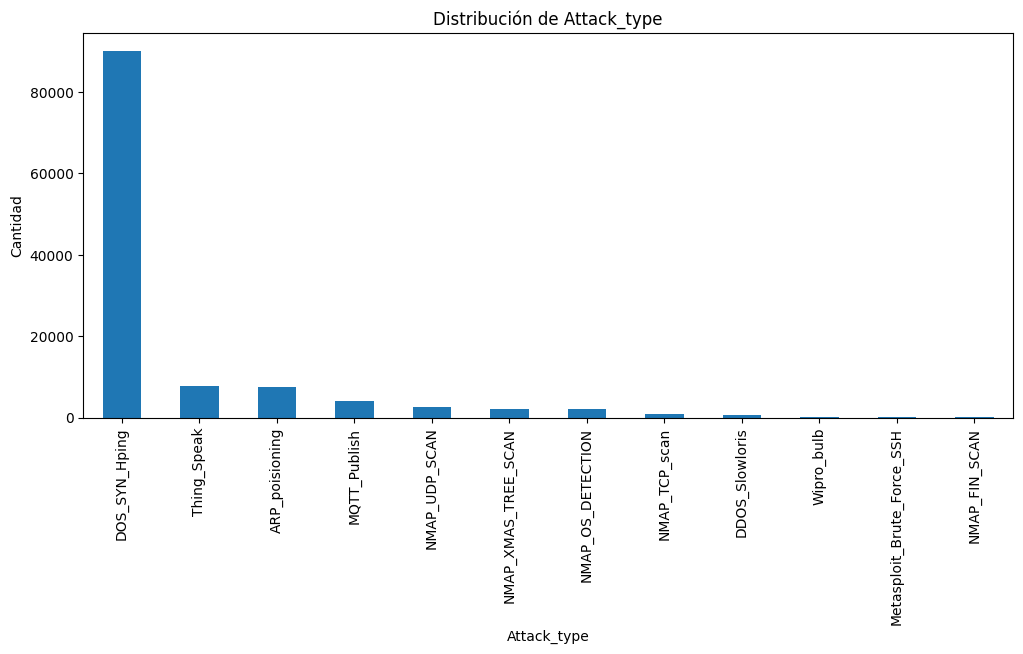

In [29]:
import matplotlib.pyplot as plt

y.value_counts().plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Distribución de Attack_type")
plt.ylabel("Cantidad")
plt.show()

# División Train/Test con estratificación

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## Verificar tamaños

In [31]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (94337, 36)
X_test : (23585, 36)
y_train: (94337,)
y_test : (23585,)


# Verificar que la estratificación funcionó

In [32]:
#Distribución original:
(
    y.value_counts(normalize=True)
    * 100
).round(2)

,proportion
Attack_type,
DOS_SYN_Hping,76.40
Thing_Speak,6.49
ARP_poisioning,6.47
MQTT_Publish,3.51
NMAP_UDP_SCAN,2.19
NMAP_XMAS_TREE_SCAN,1.70
NMAP_OS_DETECTION,1.70
NMAP_TCP_scan,0.85
DDOS_Slowloris,0.45


In [33]:
#Distribución en train:
(
    y_train.value_counts(normalize=True)
    * 100
).round(2)

,proportion
Attack_type,
DOS_SYN_Hping,76.40
Thing_Speak,6.49
ARP_poisioning,6.47
MQTT_Publish,3.51
NMAP_UDP_SCAN,2.19
NMAP_XMAS_TREE_SCAN,1.70
NMAP_OS_DETECTION,1.70
NMAP_TCP_scan,0.85
DDOS_Slowloris,0.45


In [34]:
#Distribución en test:
(
    y_test.value_counts(normalize=True)
    * 100
).round(2)

,proportion
Attack_type,
DOS_SYN_Hping,76.40
Thing_Speak,6.49
ARP_poisioning,6.47
MQTT_Publish,3.51
NMAP_UDP_SCAN,2.19
NMAP_XMAS_TREE_SCAN,1.70
NMAP_OS_DETECTION,1.70
NMAP_TCP_scan,0.85
DDOS_Slowloris,0.45


# Análisis de escalamiento

## Evaluación de escalamiento

Se identificó que las variables poseen escalas muy diferentes.

Ejemplos:
- flow_duration
- flow_pkts_per_sec
- idle.tot
- fwd_init_window_size

Se revisaron tres métodos:

- StandardScaler
- MinMaxScaler
- RobustScaler

In [35]:
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)

print("StandardScaler")
print(StandardScaler())

print("MinMaxScaler")
print(MinMaxScaler())

print("RobustScaler")
print(RobustScaler())

StandardScaler
StandardScaler()
MinMaxScaler
MinMaxScaler()
RobustScaler
RobustScaler()


# Conclusiones finales

## Conclusiones

- Se separó correctamente la variable objetivo Attack_type.
- Se identificó un desbalance importante entre clases.
- Se utilizó una división 80/20.
- Se aplicó estratificación para conservar la distribución de clases.
- Los modelos basados en árboles no requerirán escalamiento inicialmente.
- Para modelos sensibles a la escala se utilizará StandardScaler.